In [1]:
pip install nbimporter

Note: you may need to restart the kernel to use updated packages.


In [2]:
import nbimporter
from GA_Wisdom_Crowds import *
import pandas as pd
import random

In [107]:
import time
tsp_file = "Random222.tsp"
start_time = time.time()

table_list = []
for i in range(1):
    row_list = []
    start_time = time.time()
    a,b, c = main(tsp_file = tsp_file, max_it = 100, convergence_lim = 5, gen_size = 30)
    end_time = time.time()
    print("Runtime:", end_time - start_time, "seconds")
    rt = end_time - start_time
    shortest_distance = b.loc[1, "Distance"]
    print(shortest_distance)
    
    generation = b.loc[1, "Generation"]
    
    print(generation)
    row_list.append(shortest_distance)
    row_list.append(generation)
    row_list.append(rt)
    table_list.append(row_list)
    
import pandas as pd

df = pd.DataFrame(table_list)
df

Runtime: 1110.9337882995605 seconds
1240.6288163564466
21


,0,1,2
0,1240.628816,21,1110.933788


In [115]:
 b.loc[1, "Path_String"]

'City 6 => City 4 => City 5 => City 9 => City 2 => City 11 => City 8 => City 10 => City 3 => City 7 => City 1 => City 6'

In [111]:
b

,Path_ID,_Path,Generation,Crossover,Mutation,ParentA_ID,ParentB_ID,Path_String,Distance
0,382,[<GA_Wisdom_Crowds.City object at 0x000001C285...,9,A,A,360,367,City 6 => City 4 => City 5 => City 9 => City 2...,351.045880
1,409,[<GA_Wisdom_Crowds.City object at 0x000001C285...,10,A,A,382,393,City 6 => City 4 => City 5 => City 9 => City 2...,351.045880
2,436,[<GA_Wisdom_Crowds.City object at 0x000001C285...,11,A,A,403,382,City 6 => City 4 => City 5 => City 9 => City 2...,351.045880
3,488,[<GA_Wisdom_Crowds.City object at 0x000001C285...,13,A,A,436,409,City 6 => City 4 => City 5 => City 9 => City 2...,351.045880
4,485,[<GA_Wisdom_Crowds.City object at 0x000001C285...,13,A,A,409,458,City 6 => City 4 => City 5 => City 9 => City 2...,351.045880
10,505,[<GA_Wisdom_Crowds.City object at 0x000001C285...,14,A,A,488,484,City 6 => City 4 => City 5 => City 9 => City 2...,351.045880
24,519,[<GA_Wisdom_Crowds.City object at 0x000001C285...,14,B,A,484,475,City 6 => City 4 => City 5 => City 9 => City 2...,351.919142
12,507,[<GA_Wisdom_Crowds.City object at 0x000001C2A7...,14,A,A,431,430,City 2 => City 11 => City 8 => City 10 => City...,351.919142
18,513,[<GA_Wisdom_Crowds.City object at 0x000001C285...,14,A,A,480,382,City 6 => City 4 => City 5 => City 9 => City 2...,351.919142
26,521,[<GA_Wisdom_Crowds.City object at 0x000001C285...,14,B,B,478,431,City 6 => City 4 => City 9 => City 5 => City 2...,359.684601


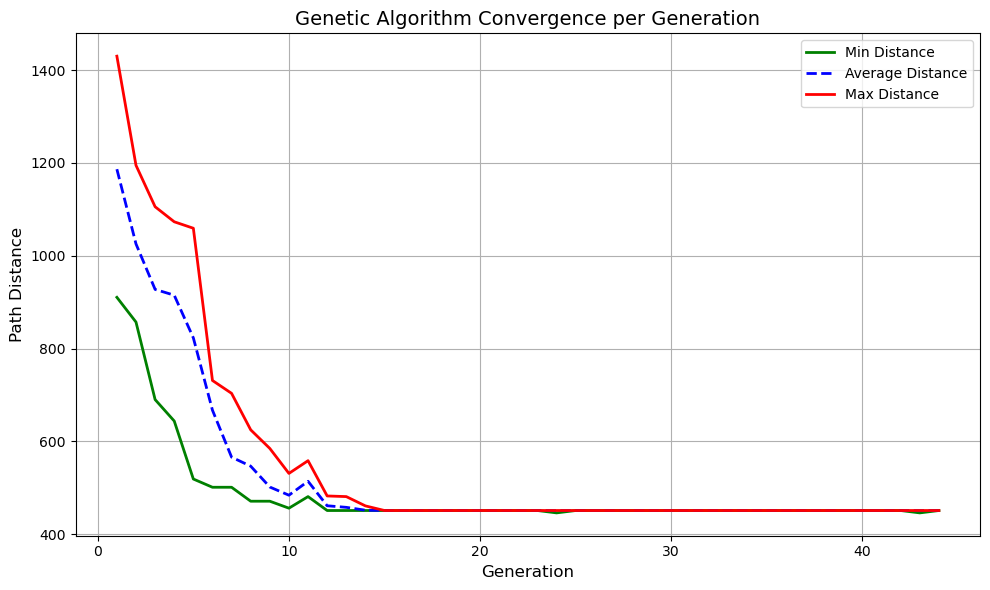

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Compute summary stats per generation
summary = (
    a.groupby("Generation")["Distance"]
      .agg(["min", "mean", "max"])
      .reset_index()
)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(summary["Generation"], summary["min"], label="Min Distance", color="green", linewidth=2)
plt.plot(summary["Generation"], summary["mean"], label="Average Distance", color="blue", linestyle="--", linewidth=2)
plt.plot(summary["Generation"], summary["max"], label="Max Distance", color="red", linewidth=2)

plt.title("Genetic Algorithm Convergence per Generation", fontsize=14)
plt.xlabel("Generation", fontsize=12)
plt.ylabel("Path Distance", fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


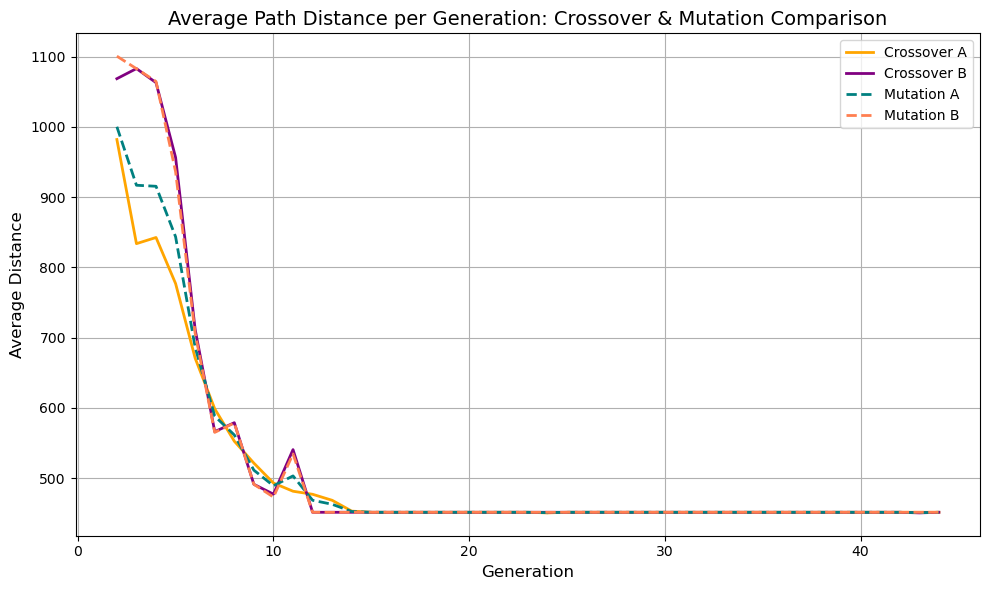

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Compute averages for Crossover and Mutation ---
avg_crossover = (
    a.groupby(["Generation", "Crossover"])["Distance"]
      .mean()
      .reset_index()
      .pivot(index="Generation", columns="Crossover", values="Distance")
)

avg_mutation = (
    a.groupby(["Generation", "Mutation"])["Distance"]
      .mean()
      .reset_index()
      .pivot(index="Generation", columns="Mutation", values="Distance")
)

# --- Plot both on same figure ---
plt.figure(figsize=(10, 6))

# Crossover lines (solid)
plt.plot(avg_crossover.index, avg_crossover.get('A'), color="orange", linewidth=2, label="Crossover A")
plt.plot(avg_crossover.index, avg_crossover.get('B'), color="purple", linewidth=2, label="Crossover B")

# Mutation lines (dashed)
plt.plot(avg_mutation.index, avg_mutation.get('A'), color="teal", linestyle="--", linewidth=2, label="Mutation A")
plt.plot(avg_mutation.index, avg_mutation.get('B'), color="coral", linestyle="--", linewidth=2, label="Mutation B")

# --- Labels and layout ---
plt.title("Average Path Distance per Generation: Crossover & Mutation Comparison", fontsize=14)
plt.xlabel("Generation", fontsize=12)
plt.ylabel("Average Distance", fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
